# 4. Bandes de phonons 


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.ext.matproj import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter

from scipy.optimize import curve_fit
from scipy.constants import hbar, k as k_B

API_KEY = "vKJsFu0jdhLy7CJj5Mwar6S68kxgMc3n"
MP_ID = "mp-1008556"  

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(MP_ID)
    phonon_bs = mpr.get_phonon_bandstructure_by_material_id(MP_ID)

## 4.1 Télécharger la structure de bandes de phonons du matériau attribué ainsi que sa zone de Brillouin

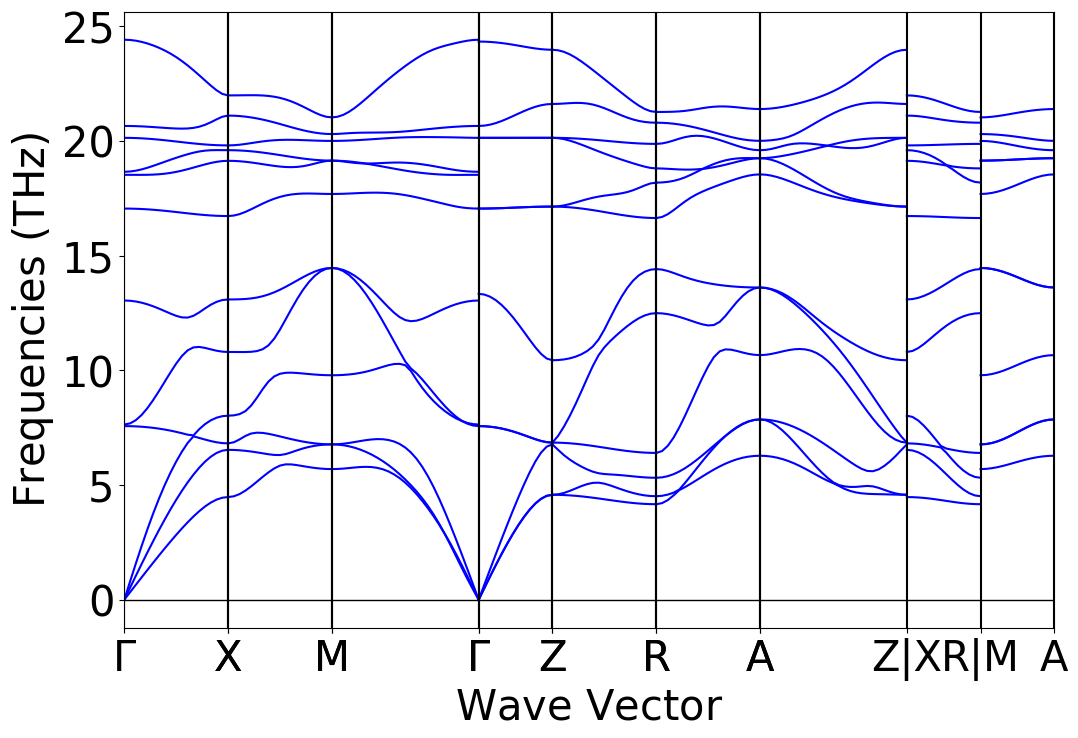

In [3]:
plotter = PhononBSPlotter(phonon_bs)
fig = plotter.get_plot()  

plt.savefig(f"{MP_ID}_phonon_bandstructure.png", dpi=300, bbox_inches="tight")
plt.show()

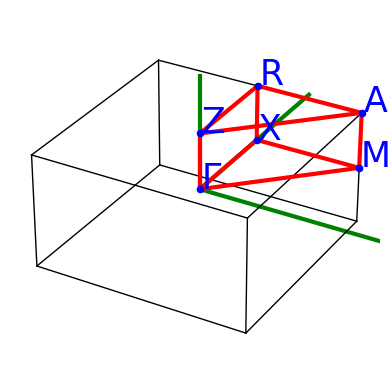

In [4]:
# Zone de Brillouin
ph_plot = PhononBSPlotter(phonon_bs)
ph_plot.plot_brillouin()

## 4.2 déterminer les trois premiers pics du diffractogramme correspondant (en indiquant les indices hkl associés) pour un rayonnement X incident Cu Kα de longueur d'onde λ=1.54060 Å.

In [ ]:
# besoin des paramètres de maille de ton matériau ($a, b, c$) pour utiliser la loi de Bragg :n*lambda = 2d_{hkl}*sin(theta)

## 4.3 calculer la vitesse du son pour trois branches acoustiques différentes dans trois directions différentes de la zone de Brillouin;

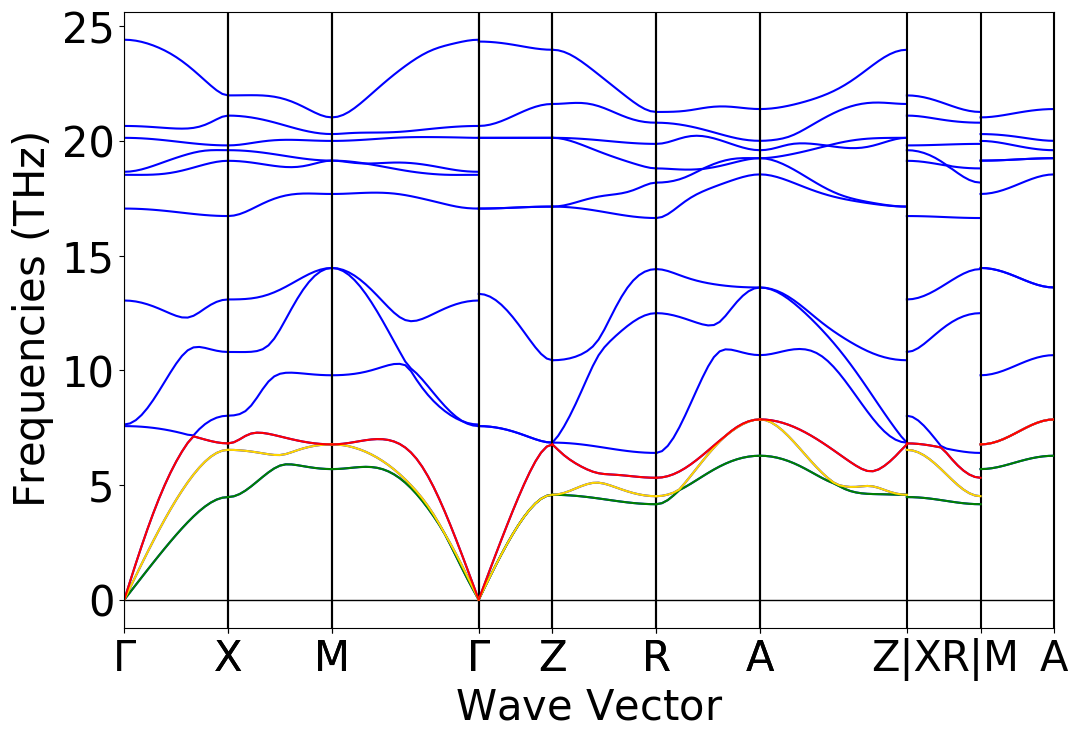

In [5]:
data = PhononBSPlotter(phonon_bs).bs_plot_data()
distances = data['distances']
frequences = data['frequency']
directions = data['ticks']['label']

ph_plot.get_plot()

for i in range(len(distances)):
    plt.plot(distances[i], frequences[i][0], 'green')
    plt.plot(distances[i], frequences[i][1], 'gold')
    plt.plot(distances[i], frequences[i][2], 'red')


In [ ]:
conversion = 1e12 / 1e10
# Vitesse v = 2 * pi * df / dq

# signification des indices de frequences : [chemin/e/2points][branche][val_freq_pour_ce_point]
# signification des indices de distances : [chemin/e/2points][coord_q_axeH]

# 1ere branche acoustique Gamma - X
d_freq1 = (frequences[0][2][1] - frequences[0][2][0])
d_dist1 = distances[0][1] - distances[0][0]

v_1 = np.abs(2 * np.pi * (d_freq1 / d_dist1) * conversion)
print(f"La vitesse du son pour la branche Γ-X de la zone de Brillouin :  {v_1:.2f} [m/s]")

# 2eme branche acoustique Gamma - Z
d_freq2 = frequences[3][2][1] - frequences[3][2][0]
d_dist2 = distances[3][1] - distances[3][0]

v_2 =  np.abs(2 * np.pi * (d_freq2 / d_dist2) * conversion)
print(f"La vitesse du son pour la branche Γ-Z de la zone de Brillouin : {v_2:.2f} [m/s]")

# 3eme branhce acoustiqye Gamma - M
d_freq3 = frequences[2][2][-1] - frequences[2][2][-2]
d_dist3 = distances[2][-1] - distances[2][-2]

v_3 =  np.abs(2 * np.pi * (d_freq3 / d_dist3) * conversion)
print(f"La vitesse du son pour la branche X-M de la zone de Brillouin : {v_3:.2f} [m/s]")

La vitesse du son pour la branche Γ-X de la zone de Brillouin :  8964.42 [m/s]
La vitesse du son pour la branche Γ-Z de la zone de Brillouin : 7602.32 [m/s]
La vitesse du son pour la branche X-M de la zone de Brillouin : 7694.99 [m/s]


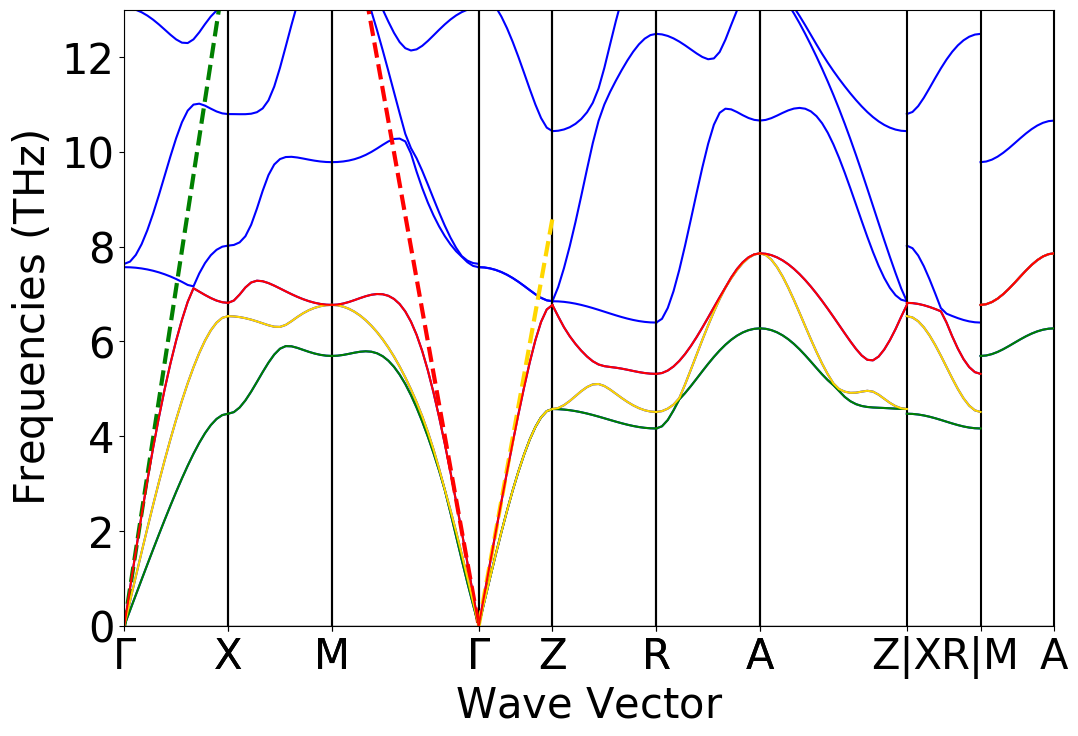

In [ ]:
ph_plot.get_plot()
plt.plot()

# direction 1
x1 = np.array([distances[0][0], distances[0][1]])
y1 = np.array([frequences[0][2][0], frequences[0][2][1]])
c1 = np.polyfit(x1, y1, 1)
a1 = np.linspace(distances[0][0], distances[0][-1], 100)
p1 = c1[0]*a1 + c1[1]

# direction 2
x2 = np.array([distances[3][0], distances[3][1]])
y2 = np.array([frequences[3][2][0], frequences[3][2][1]])
c2 = np.polyfit(x2, y2, 1)
a2 = np.linspace(distances[3][0], distances[3][-1], 100)
p2 = c2[0]*a2 + c2[1]

# direction 3
x3 = np.array([distances[2][-2], distances[2][-1]])
y3 = np.array([frequences[2][2][-2], frequences[2][2][-1]])
c3 = np.polyfit(x3, y3, 1)
a3 = np.linspace(distances[2][0], distances[2][-1], 100)
p3 = c3[0]*a3 + c3[1]


plt.plot(a1, p1, color ="green", ls='--', lw = 3)
plt.plot(a2, p2, color ="gold", ls='--', lw = 3)
plt.plot(a3, p3, color='red', ls='--', lw = 3)
plt.ylim(0,13)
for i in range(len(distances)):
    plt.plot(distances[i], frequences[i][0], 'green')
    plt.plot(distances[i], frequences[i][1], 'gold')
    plt.plot(distances[i], frequences[i][2], 'red')